## PDS PRACTICAL 7

**NAME: VARAD VIJAY AMBEKAR**

**DIV: SY-A**

**ROLL NO.: A-02**

**AIM: Implement and analyze various probability distributions in Python, including Binomial, Poisson, and Normal distributions.**

**1. Difference between Binomial, Poisson, and Normal distributions**

* Binomial Distribution is a discrete distribution used when there is a fixed number of trials and each trial has only two outcomes (success or failure) with constant probability.

* Poisson Distribution is a discrete distribution used to model the number of events occurring in a fixed interval of time or space when events happen independently.

* Normal Distribution is a continuous distribution that is symmetric and bell-shaped, defined by mean and standard deviation.

In short:

Binomial → fixed trials
Poisson → event counts
Normal → continuous data

**2. Real-world significance of Poisson distribution**

Poisson distribution is used to model real-life situations where we count how many times an event occurs in a given interval.

Examples:

Number of calls received in a call center
Number of accidents in a day
Number of website visitors per minute

It is important because it helps in predicting and managing systems like traffic, networks, and queues.

**3. Central Limit Theorem (CLT)**

The Central Limit Theorem states that:

When the sample size is large, the distribution of the sample mean tends to become normal, regardless of the original distribution.

This means even if the data is not normally distributed, the average of samples will follow a normal distribution.

**4. Why Normal distribution is widely used**

Normal distribution is widely used because:

Many natural and real-world data follow this pattern
It is mathematically simple to work with
It is used in many statistical methods and machine learning models

Examples:

Heights of people
Exam scores
Measurement errors
**5. What is skewness and which distributions exhibit it**

Skewness refers to the asymmetry of a distribution.

Positive skew → tail on right side
Negative skew → tail on left side
Zero skew → symmetric distribution

Distribution behavior:

Binomial → can be skewed or symmetric
Poisson → usually positively skewed
Normal → no skew (perfectly symmetric)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/train (1).csv")

print(df.head())
print(df.info())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

In [ ]:
data = df.select_dtypes(include=['number']).iloc[:, 0]

print("Selected column:", data.name)

Selected column: PassengerId


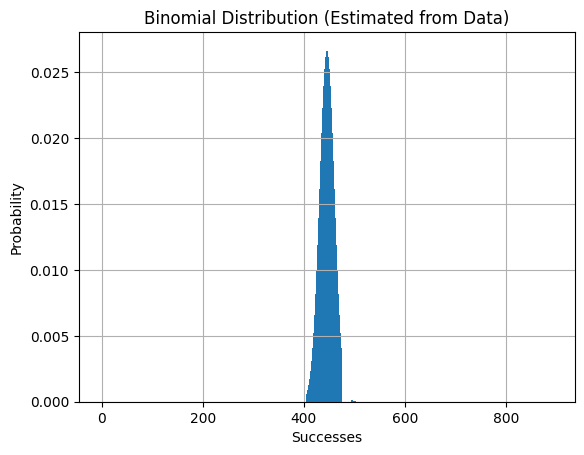

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

n = int(max(data))
p = np.mean(data) / n

x = np.arange(0, n+1)
pmf = binom.pmf(x, n, p)

plt.bar(x, pmf)
plt.title("Binomial Distribution (Estimated from Data)")
plt.xlabel("Successes")
plt.ylabel("Probability")
plt.grid()
plt.show()

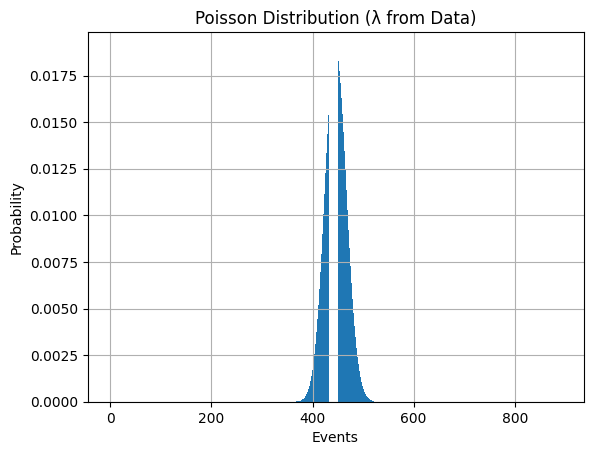

In [ ]:
from scipy.stats import poisson

lam = np.mean(data)

x = np.arange(0, int(max(data))+1)
pmf = poisson.pmf(x, lam)

plt.bar(x, pmf)
plt.title("Poisson Distribution (λ from Data)")
plt.xlabel("Events")
plt.ylabel("Probability")
plt.grid()
plt.show()


In [ ]:
variance = np.var(data)

print("Mean:", lam)
print("Variance:", variance)

if abs(lam - variance) < 1:
    print(" Data may follow Poisson distribution")
else:
    print(" Data does NOT follow Poisson properly")

Mean: 446.0
Variance: 66156.66666666667
 Data does NOT follow Poisson properly


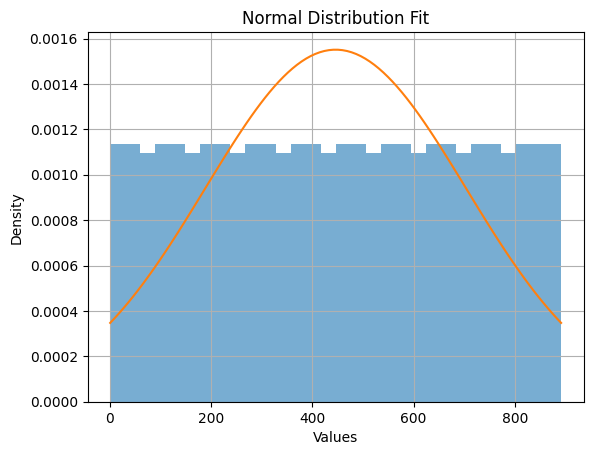

In [ ]:
from scipy.stats import norm

mu = np.mean(data)
sigma = np.std(data)

x = np.linspace(min(data), max(data), 100)
pdf = norm.pdf(x, mu, sigma)

plt.hist(data, bins=30, density=True, alpha=0.6)
plt.plot(x, pdf)
plt.title("Normal Distribution Fit")
plt.xlabel("Values")
plt.ylabel("Density")
plt.grid()
plt.show()

In [ ]:
from scipy.stats import shapiro

stat, p = shapiro(data)

print("p-value:", p)

if p > 0.05:
    print(" Data is approximately Normal")
else:
    print(" Data is NOT Normal")

p-value: 6.308055732378686e-16
 Data is NOT Normal


In [ ]:
from scipy.stats import skew

sk = skew(data)
print("Skewness:", sk)

if sk > 0:
    print("Right skewed")
elif sk < 0:
    print("Left skewed")
else:
    print("Symmetric")

Skewness: 0.0
Symmetric


**CONCLUSION:**

In this practical, Binomial, Poisson, and Normal distributions were implemented and analyzed using Python. The dataset was examined by calculating statistical measures such as mean, variance, and skewness, and by visualizing the data using graphs.

From the analysis, it was observed that:

The Normal distribution provides a good fit when the data is continuous and symmetric.
The Poisson distribution is suitable when the mean and variance of the data are approximately equal, indicating event-based data.
The Binomial distribution is applicable only when the data represents a fixed number of trials with two possible outcomes.